In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import glob 
import os
import re
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42  
mpl.rcParams['ps.fonttype'] = 42

#defining colors
purple = mcolors.to_rgba('#4A1B4F')
pink = mcolors.to_rgba('#CC2A57')
blue = mcolors.to_rgba('#417CBF')
green = mcolors.to_rgba('#23967C')
yellow = mcolors.to_rgba('#D9A433')
grey = mcolors.to_rgba('#595959')
colors = [purple, pink, blue, green, yellow, grey]

plt.rcParams.update({
    'font.size': 12, #6
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'lines.linewidth': 1, #0.3
    'xtick.direction': 'inout',
    'ytick.direction': 'inout',   
    'axes.linewidth': 1.25,   #0.5     
})

plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5

In [30]:
#function to make the calibration curve, it will show the plot if you uncomment below
def calcurve(filepath, color):
    with open(filepath) as file:
        lines = file.readlines()
    start_marker_cal = '[GPC Calibration Curve Table(Detector B)]'  
    end_marker_cal = 'Comment' 
    start_index_cal = next((i for i, line in enumerate(lines) if start_marker_cal in line), None)+2
    end_index_cal = (next((i for i, line in enumerate(lines) if end_marker_cal in line), None))-2
    lines_to_skip = list(range(0, start_index_cal)) + list(range(end_index_cal+1, len(lines)))
    calcurve = pd.read_csv(filepath, skiprows=lines_to_skip, header=0, delimiter='\t')
    calcurve = calcurve.drop(['#', 'Weight', 'Error', 'Active','Virtual','Data Name'], axis=1)
    calcurve['log(MW)'] = np.log10(calcurve['M.W.'])
    
    x = calcurve['Time(min)'].values
    y = calcurve['log(MW)'].values

    coeff = np.polyfit(x,y,3)
    poly_function = np.poly1d(coeff)

    x_values = np.linspace(min(x), max(x), 100)
    y_values = poly_function(x_values)

    # plotting, if you want to see the cal curve, uncomment this, and define color as whichever you want
    # color = purple
    # plt.scatter(x, y, color=color, marker='o') 
    # plt.plot(x_values, y_values, label=str(poly_function), color=color, linestyle='--')
    # plt.xlabel('time (min)')
    # plt.ylabel('log(MW)')
    # plt.title('Calibration Curve')
    # plt.legend(loc='upper center')
    # plt.grid(False)
    # plt.show()
        
    return poly_function

In [43]:
def process(filepath, csvout, color, blank):
    poly_function = calcurve(filepath, color)
    with open(filepath) as file:
        lines = file.readlines()
    
    #start and end markers of pulling data from the text file
    start_marker = '[LC Chromatogram(Detector B-Ch1)]'  
    end_marker = '[LC Status Trace(Pump A Pressure)]' 
    
    #indices for where data being pulled from the text file
    start_index = next((i for i, line in enumerate(lines) if start_marker in line), None)+7
    end_index = (next((i for i, line in enumerate(lines) if end_marker in line), None))-1
    
    #defines which lines to skip so those between are pulled from the text file
    lines_to_skip = list(range(0, start_index)) + list(range(end_index+1, len(lines)))

    with open(blank) as file:
        lines_blank = file.readlines()
    start_index_blank = next((i for i, line in enumerate(lines_blank) if start_marker in line), None)+7
    end_index_blank = (next((i for i, line in enumerate(lines_blank) if end_marker in line), None))-1

    lines_to_skip_blank = list(range(0, start_index_blank)) + list(range(end_index_blank+1, len(lines_blank)))
    
    #processing values; apply the function from the cal curve to the retention times to get MW_PEG; normlalize intensity
    blank = pd.read_csv(blank, skiprows=lines_to_skip_blank, header=0, delimiter='\t')
    df = pd.read_csv(filepath, skiprows=lines_to_skip, header=0, delimiter='\t')
    # print("b", blank)
    # print("df", df)

    # df['Intensity'] -= blank['Intensity'].values
    
    start = df.index[df['R.Time (min)'] == 10].tolist()[0]
    end = df.index[df['R.Time (min)'] == 25].tolist()[0]
    rows = range(start, end)
    columns = ['R.Time (min)', 'Intensity']
    data = df.loc[rows, columns]
    # print('data', data)
    
    blank_data = blank.loc[rows, columns]
    # print('blank', blank_data)
    data['Intensity'] -= blank_data['Intensity'].values
    
    data['MW_PEG'] = poly_function(data['R.Time (min)'])
    data['MW_PEG'] = 10 ** data['MW_PEG']
    max_intensity = data['Intensity'].max()
    min_intensity = data['Intensity'].min()

    data['normalized RI'] = (data['Intensity'] - min_intensity) / (max_intensity - min_intensity)
    data.to_csv(csvout, index=False)
    
    processed = data[['MW_PEG', 'normalized RI']]
    max_y_row = processed.loc[processed['normalized RI'].idxmax()]
    # print(filepath)
    # print(max_y_row['MW_PEG']) #prints Mp

    return processed



In [54]:
def plotting(directory, title, x_min, x_max, colors, labels, plotout, csvout, blank, lines):
    
    # file_list = [os.path.join(directory, f) for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))]
    file_list = [os.path.join(directory, f) for f in os.listdir(directory) if f.endswith('.txt') and os.path.isfile(os.path.join(directory, f))]
    file_list.sort(key=natural_sort_key)
    # file_list = {os.path.splitext(f)[0]: os.path.join(directory, f) for f in os.listdir(directory) if f.endswith('.txt')}
   
    fig = plt.figure(figsize=(5,5))
    for idx, filename in enumerate (file_list):
        color = colors[idx % len(colors)]
        line = lines[idx % len(lines)]
        df = process(filename, csvout, color, blank)
        
        plt.plot(df['MW_PEG'], df['normalized RI'], color=color, label=f'Trace {idx+1} ({filename})', linestyle=line)
        labels.append(f'Trace {idx+1} ({filename})')

    plt.gca().spines['top'].set_color('none')
    plt.gca().spines['right'].set_color('none')
    plt.xlabel('MW$_P$$_E$$_G$ (Da)')
    plt.ylabel('normalized RI')
    plt.title(title)
    plt.legend(labels=labels)
    plt.xlim(x_min,x_max)
    plt.ylim(0,1.1)
        
    plt.show()
    
    fig.savefig(plotout, format='pdf')

In [55]:
def anumlist():
    letters = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
    numbers = range(1, 13)  # Generates numbers from 1 to 12

    alphanumeric_list = []

    for letter in letters:
        for number in numbers:
            alphanumeric_list.append(f"{letter}{number}")

    return alphanumeric_list

def natural_sort_key(file_path):
    filename = os.path.basename(file_path)
    return [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', filename)]

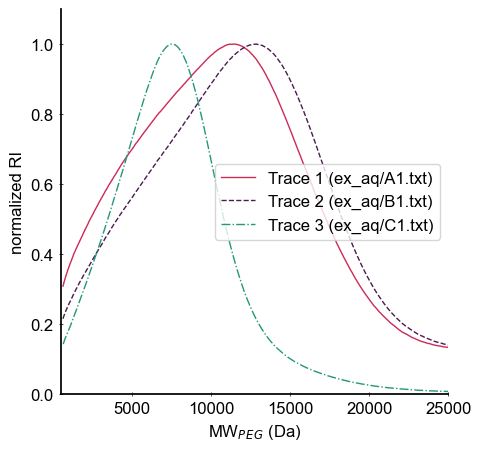

In [57]:
directory = 'ex_aq'
blank = 'ex_aq/blanks/blank.txt'
title = ''
x_min = 500
x_max = 25000
plot_output_file = 'aq_example.pdf'
lines = ['-', '--', '-.', '-', '--', '-.']

colors = [pink, purple, green, ]

labels=[]

#here you need to define the filepath you want to save the raw data to, must be in quotes, will be saved as a csv file
csv_output_file = 'aq_example.csv'

plotting(directory, title, x_min, x_max, colors, labels, plot_output_file, csv_output_file, blank, lines)